# Análise de Vendas de Videogames

A loja online Ice vende videogames pelo mundo todo e precisa identificar, a partir de dados históricos de vendas, avaliações de críticos e usuários, gêneros e classificações etárias, quais títulos têm maior potencial de sucesso. O objetivo é orientar as campanhas publicitárias de 2017.

A análise cobre o tratamento e a padronização da base, o estudo do ciclo de vida das plataformas, a relação entre avaliações e vendas, o perfil de consumo de América do Norte, Europa e Japão, e testes de hipótese sobre as diferenças de avaliação entre plataformas e entre gêneros.

In [2]:
#Catrregando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

In [3]:
#Carregando os dados
df = pd.read_csv('/datasets/games.csv')
#Obtendo uma primeira visão dos dataframe
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
#Ajustando os nomes das colunas
new_col = []
for old_names in df.columns: #Para cada nome antigo de colunas no dataframe
	name_lower = old_names.lower() #Padronizar em minúsculas para legibilidade
	new_col.append(name_lower)#Montar novo df

#Atribuindo os novos nomes ao df
df.columns = new_col

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Analisando as informações fornecidas do método .info(), podemos perceber que as colunas 'year_of_release' e 'user_score' não estão com os tipos corretos. O ano de lançamento deve ser tratado como int, enquanto a avaliação dos usuários deve ser considerada float, pois trabalha com valores decimais.

In [6]:
#Corrigindo os tipos das colunas
df['year_of_release'] = df['year_of_release'].astype('Int64')
#Investigando erro na conversão da coluna 'usser_score'
print(df['user_score'].unique())
print(df['user_score'].value_counts())

['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4' '8.2' '9' '7.9'
 '8.1' '8.7' '7.1' '3.4' '5.3' '4.8' '3.2' '8.9' '6.4' '7.8' '7.5' '2.6'
 '7.2' '9.2' '7' '7.3' '4.3' '7.6' '5.7' '5' '9.1' '6.5' 'tbd' '8.8' '6.9'
 '9.4' '6.8' '6.1' '6.7' '5.4' '4' '4.9' '4.5' '9.3' '6.2' '4.2' '6' '3.7'
 '4.1' '5.8' '5.6' '5.5' '4.4' '4.6' '5.9' '3.9' '3.1' '2.9' '5.2' '3.3'
 '4.7' '5.1' '3.5' '2.5' '1.9' '3' '2.7' '2.2' '2' '9.5' '2.1' '3.6' '2.8'
 '1.8' '3.8' '0' '1.6' '9.6' '2.4' '1.7' '1.1' '0.3' '1.5' '0.7' '1.2'
 '2.3' '0.5' '1.3' '0.2' '0.6' '1.4' '0.9' '1' '9.7']
tbd    2424
7.8     324
8       290
8.2     282
8.3     254
       ... 
1.1       2
1.9       2
0.9       2
0         1
9.7       1
Name: user_score, Length: 96, dtype: int64


A falha na conversão ocorreu pois alguns dos jogos estão com a nota dos usuário com valor em string(tbd/To Be Defined), o pandas entende que uma coluna com texto deve ser  objeto. Nesse contexto, optei por substituir a string 'tbd' em NaN, valor compatível com o tipo float.

In [7]:
#Corrigindo o tipo da coluna 'user_score', substituindo string tbd por valores ausentes
df['user_score'] = df['user_score'].replace('tbd', np.nan).astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


Considerando o tamanho do dataset com 16715 linhas, optei por remover os dados ausentes nas colunas 'name', 'year_of_release' e 'genre'. A remoção dos valores ausentes dessas colunas não compromete a análise completa, e garante uma melhor qualidade dos dados.

In [8]:
# Removendo as linhas com nulos nas colunas essenciais
df = df.dropna(subset=['name', 'genre', 'year_of_release'])

A coluna 'rating' se refere a classificação etária, e pode ser útil para análise agrupar por essa categoria. Com isso em consideração, decidi por preencher os valores ausentes na coluna por 'Unknown', preservando os dados.

In [9]:
# Substitui NaN por 'Unknown'
df['rating'] = df['rating'].fillna('Unknown')

Considerando o contexto das colunas, acredito que a maioria dos valores ausentes se deu por falta de tempo e informações para avaliar os jogos. Essa hipótese foi desenvolvida baseado em 2 ideias. Primeiramente, 2424 valores na coluna 'user_score' estavam como 'tbd', que significa 'Á ser definido', indicando que ainda não houve uma definição sobre a avaliação dos usuários sobre o jogo. A segunda ideia seria que 2 das 3 colunas com mais valores ausentes seriam colunas avaliativas, 'user_score' e 'critic_score', indicando que o processo de avaliação depende de alguns fatores. Entre elas, acredito que críticos podem priorizar os jogos populares, sendo ausentes em jogos com menor número de vendas, usuários formam suas opiniões baseado na sua experiência do jogo, para jogos recentes , talvez eles não tenham formado sua opinião ainda. Por fim, é possivel que jogos mais antigos não tinham uma comunidade desenvolvida no sentido de criar e buscar plataformas para avaliações dos jogadores.

In [10]:
#Calculando a soma total de vendas
df['total_sales'] = df['na_sales']+df['eu_sales']+df['jp_sales']+df['other_sales']
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,Unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,Unknown,31.38


<AxesSubplot:title={'center':'Número de jogos por ano de lançamento'}, xlabel='year_of_release'>

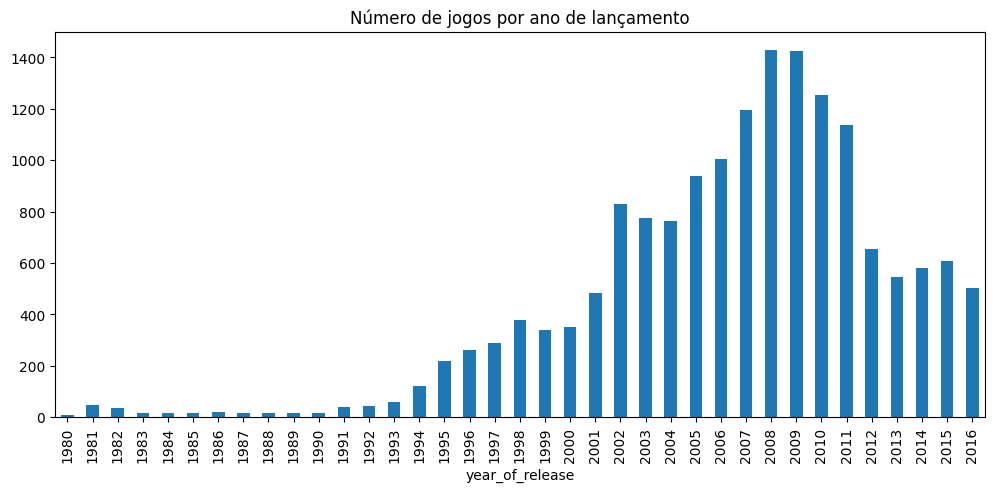

In [11]:
#Verificando jogos lançados por ano
games_per_year = df.groupby('year_of_release')['name'].count()
games_per_year.plot(kind='bar', figsize=(12, 5),title='Número de jogos por ano de lançamento')

Observando o gráfico de contagem de jogos por ano de lançamento podemos percebeer um grande crescimento nos números de jogos nos anos de 2006 a 2011, chegando ao valor máximo em 2008.

In [12]:
#Estudando a variação por plataformas em vendas históricas
platforms = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(platforms)

platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
PC       255.76
GB       254.43
XB       251.57
NES      251.05
N64      218.01
SNES     200.04
GC       196.73
XOne     159.32
2600      86.48
WiiU      82.19
PSV       53.81
SAT       33.59
GEN       28.35
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64


Observando as plataformas podemos ver uma grande diferença do top6 para as demais. Podemos ver PS, PS2 e PS3 nesse grupo seleto, enquanto o PS4 ocupa a sétima posição. Esses dados indicam, mais uma vez, o impacto do tempo. O PS4, lançado em 2014, não obteve tempo suficiente para alcançar os números de seus antecessores. Esse efeito também é visto na linha Xbox, onde o X360 se encontra em segundo lugar e sua nova versão, o XOne se encontra bastante a baixo na lista.

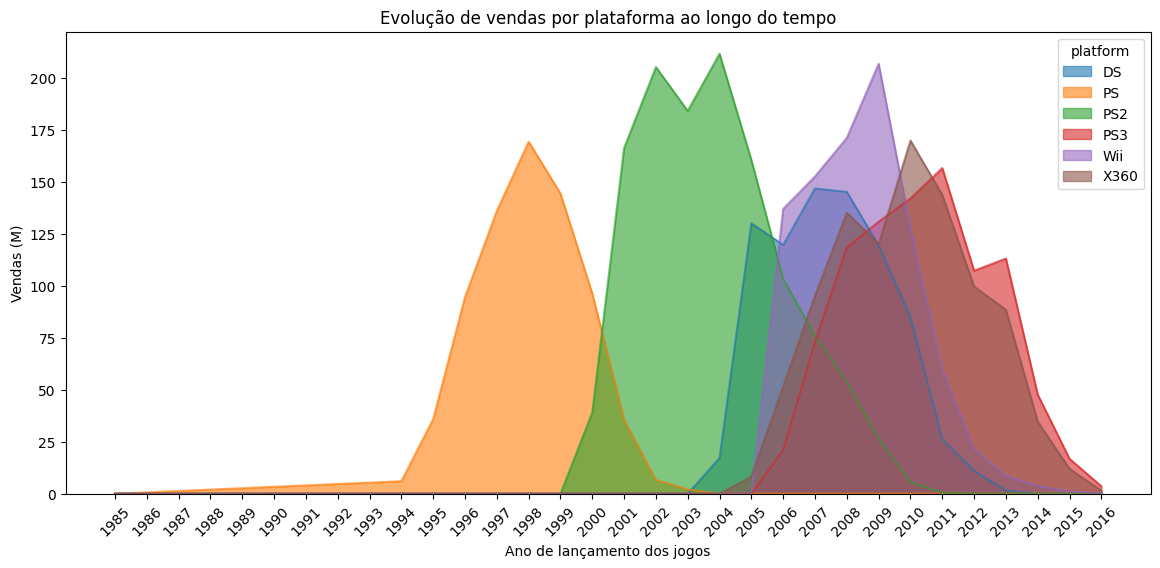

In [13]:
#Filtrando as top6 plataformas
top_platforms = platforms.head(6).index
df_top = df[df['platform'].isin(top_platforms)]

#Agrupando vendas totais por ano de lançamento em cada plataforma
sales_by_year = df_top.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack(fill_value=0)

#Criando o gráfico
sales_by_year.plot(kind='area', stacked=False, alpha=0.6, figsize=(14, 6))
plt.title('Evolução de vendas por plataforma ao longo do tempo')
plt.xlabel('Ano de lançamento dos jogos')
plt.ylabel('Vendas (M)')
plt.xticks(range(1985, 2017, 1), rotation=45)
plt.show()

Analisando o gráfico com a distribuição de vendas em cada plataforma podemos ver que todas as plataformas seguem um padrão de crescimento pico e queda. O PS começoiu a se tornar popular perto de 1994, atingiu o pico em 1997 até basicamente não vender mais jogos em 2004. O mesmo padrão pode ser visto no PS2, que surgiu em 1999 e em 2009 já não estava mais gerando vendas e o pico foi no meio desse período, em 2004. Mais uma vez o ciclo dos PS mantém seu padrão com o PS3, lançado em 2005,pico em 2011,e bendas desaparecnedo em 2016.

Considerando as outras 3 plataformas, não playstation, o comportamento ainda mantém a tendência, as plataformas não conseguem manter um nível de vendas 5 anos após seu lançamento.

Dessa forma podemos concluir que, as plataformas tem um padrão de vendas de crescimento nos 5 primeiros anos, queda nos 5 anos seguintes e terminadas em 10 anos.

Nesse contexto, para investimentosde sucesso no ano de 2017 é necessário identificar quais plataformas estão crescendo, ou seja, investir em jogos de plataformas lançadas entre 2012 e 2016.

<AxesSubplot:title={'center':'Vendas totais por plataforma (2012–2016)'}, xlabel='platform', ylabel='Vendas em (M)'>

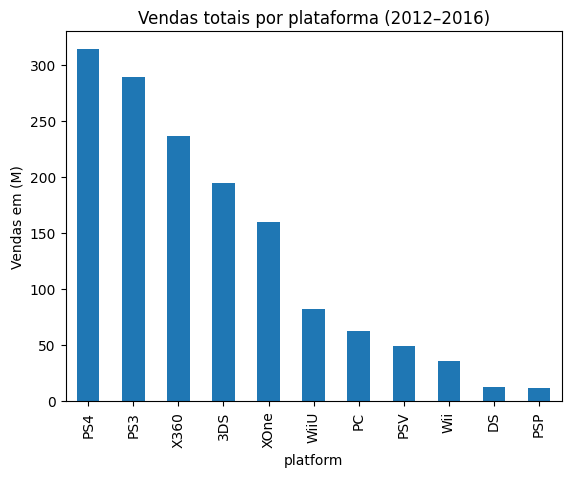

In [14]:
#Filtrando o df para os anos recentes
df_recent = df[df['year_of_release'] >= 2012]

#Estudando as vendas por plataformas no novo dataframe 
plt.title('Vendas totais por plataforma (2012–2016)')
df_recent.groupby('platform')['total_sales'].sum().sort_values(ascending=False).plot(kind='bar',ylabel='Vendas em (M)')

Podemos ver que PS4 e PS3 estão liderando as vendas. Isso corrobora com nossas conclusões anteriores, visto que o PS3 lançado no fim de 2006 teria alcançado seu pico próximo de 2012, acumulando uma grande quantidade de jogos durante seu ciclo, que justifica ele ainda gerar bastante vendas, mas se tornando menos rentável com o tempo. Enquanto o PS4, lançado no fim de 2013, está chegando exatamente no seu pico previsto no ano de 2017. 

Essa mesma tendência é refletida com os Xbox360 e XboxOne, Wii que ja se encontra velho gerando poucas vendas,sendo ultrapassado pelo Wii U, Nintendo DS e 3DS.
Nesse contexto, as melhores plataformas para investir em 2017 são PS4 e XboxOne. São as 2 plataformas no top5 (que tem um grande desnível para o sexto) que se enquadram bem no ciclo de plataformas vistos anteriormente. Os 2 foram lançados em 2013, e estaram próximo do pico no ano de 2017.

<AxesSubplot:title={'center':'total_sales'}, xlabel='platform'>

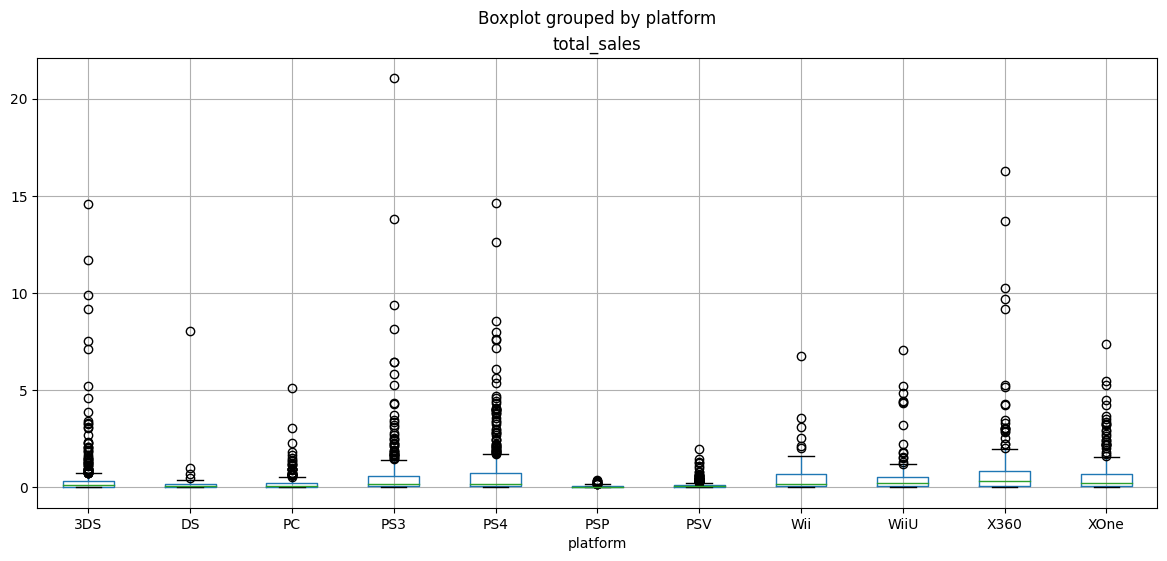

In [15]:
#Criando Boxplot para as vendas glovais de todos os jogos por plataforma
df_recent.boxplot(column='total_sales', by='platform', figsize=(14, 6))

Analisando o boxplot, podemos perceber que a mediana nas plataformas são bem similares. A grande diferença se encontra nos 'outliers' onde o PS3 conseguiu mais de 20milhões de vendas de um único título. Esse destaque nos outliers Indicam que um pequeno grupo de jogos são responsáveis pela maior parte do lucro, enquanto a maioria dos jogos são distribuídos em menos de 1 milhão de vendas. Essa descoberta sugere que a escolha da plataforma tem um impacto menor que a qualidade do jogo.

Dessa forma podemos concluir que as melhores alternativas para investimentos são jogos das plataformas PS4 e XOne com uma boa avaliação dos jogadores, portanto, jogos com avaliações melhores, seja dos jogadores 'user_score' ou dos profissionais 'critic_scores'.


              critic_score  user_score  total_sales
critic_score      1.000000    0.557654     0.406568
user_score        0.557654    1.000000    -0.031957
total_sales       0.406568   -0.031957     1.000000


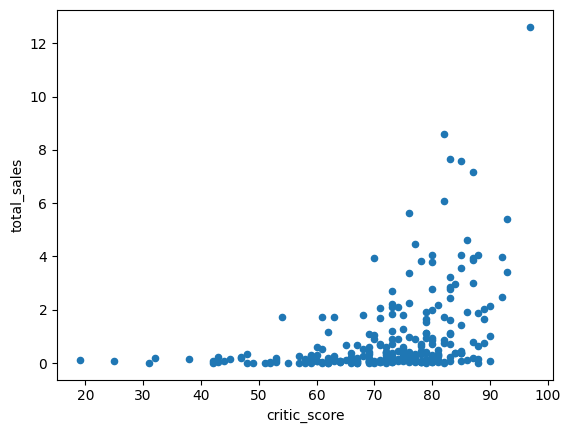

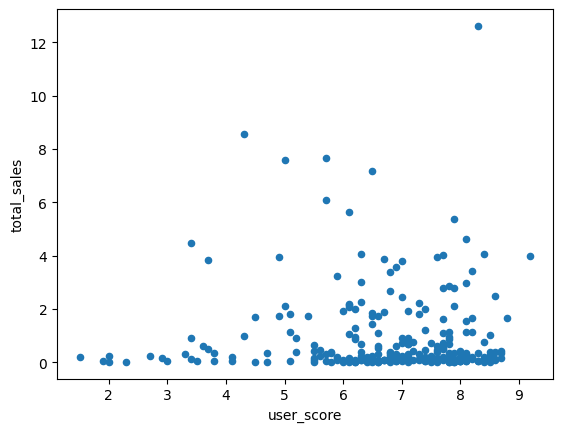

In [16]:
# Filtrando plataforma ps4
df_ps4 = df_recent[df_recent['platform'] == 'PS4']

# Gráfico de avaliações críticas
df_ps4.plot(kind='scatter', x='critic_score', y='total_sales')
#Gráfico de avaliações de usuários
df_ps4.plot(kind='scatter', x='user_score', y='total_sales')

# Calculando a correlação entre as avaliações e vendas
print(df_ps4[['critic_score', 'user_score', 'total_sales']].corr())

Analisando os gráficos de dispersão para PS4, podemos perceber que não existe uma correlação entre a avaliação dos usuários e o total de vendas. No entanto existe uma  correlação moderada entre o número de vendas e as avaliações profissionais.

Esse resultado indica que os melhores investimentos para 2017 devem levar em consideração as análises críticas dos jogos.

Text(0.5, 1.0, 'Média de vendas de jogos PS4 em outras plataformas')

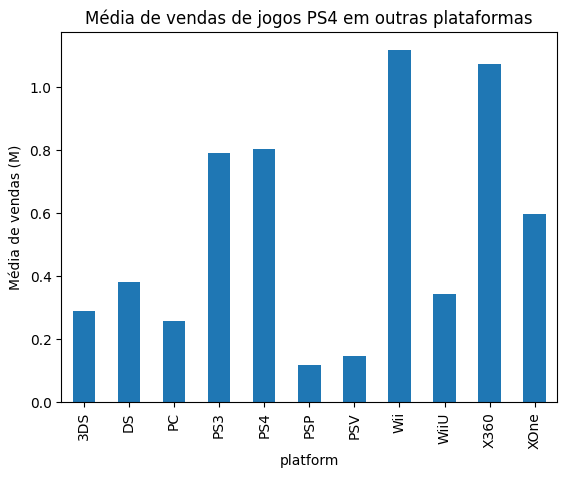

In [17]:
# Comparando vendas em plataformas diferentes
# Filtrando jogos do ps4
ps4_games = df_ps4['name'].values
# Buscando jogos do ps4 nas outras plataformas
df_crossplatform = df_recent[df_recent['name'].isin(ps4_games)]
# Criando gráfico
df_crossplatform.groupby('platform')['total_sales'].mean().plot(kind='bar')
plt.ylabel('Média de vendas (M)')
plt.title('Média de vendas de jogos PS4 em outras plataformas')

 Analisando a média de vendas de jogos ps4 em outras plataformas podemos ver que Wii e X360 tem as maiores médias. Minha teoria indica que isso ocorre pois o PS4 é um console de uma geração diferente, indicando que os títulos de Wii e Xbox360 que continuaram sendo produzidos para ps4 foram os de mais destaques. O PS3 não teve o mesmo destaque pois são consoles da mesma empresa, então tem mais incentivos para adaptar jogos de PS3 para PS4, o que aumenta os jogos totais e dilui a média.

Isso sugere que jogos disponíveis em mais plataformas tendem a ter desempenhos melhores nas plataformas antigas, possivelmente porque essas plataformas ja tinham uma base de jogadores desses jogos.

Nesse contexto, para o investimento de 2017, é importante considerar jogos com lançamentos nas plataformas atuais, ou seja, XOne e PS4.

Text(0.5, 1.0, 'Vendas de jogos por gênero')

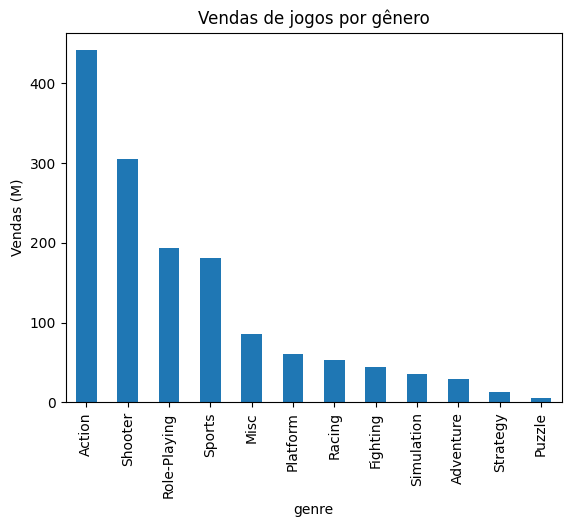

In [18]:
#Criando gráfico para analisar distribuição de vendas de jogos por gênero
df_recent.groupby('genre')['total_sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.ylabel('Vendas (M)')
plt.title('Vendas de jogos por gênero')

O gráfico revela uma clara preferência por jogos de alta interatividade e ritmo acelerado, com Action e Shooter dominando(mais de 400M e 300M respectivamente), seguidos por Role-Playing e Sports. Essa tendência sugere que jogadores priorizam experiências imersivas e competitivas.
Na outra ponta, gêneros que exigem mais raciocínio pausado como Strategy e Puzzle apresentam vendas menores, indicando menor apelo ao público geral.
No nosso contexto de ivnestimento para 2017, jogos de Action e Shooter em PS4/XOne representam a combinação com maior potencial de retorno.

In [19]:
#Filtrando os df por regiões
df_na = df_recent[['platform', 'genre', 'rating', 'na_sales']].rename(columns={'na_sales': 'sales'})
df_eu = df_recent[['platform', 'genre', 'rating', 'eu_sales']].rename(columns={'eu_sales': 'sales'})
df_jp = df_recent[['platform', 'genre', 'rating', 'jp_sales']].rename(columns={'jp_sales': 'sales'})

In [20]:
#Entendendo perfil dos jogadores de cada região
#América do norte
# plataformas
na_plat = df_na.groupby('platform')['sales'].sum().sort_values(ascending=False).head()
print(na_plat)
# gêneros
na_genre = df_na.groupby('genre')['sales'].sum().sort_values(ascending=False).head()
print(na_genre)
# rating
na_rat = df_na.groupby('rating')['sales'].sum().sort_values(ascending=False)
print(na_rat)

platform
X360    140.05
PS4     108.74
PS3     103.38
XOne     93.12
3DS      55.31
Name: sales, dtype: float64
genre
Action          177.84
Shooter         144.77
Sports           81.53
Role-Playing     64.00
Misc             38.19
Name: sales, dtype: float64
rating
M          231.57
E          114.37
Unknown    103.31
E10+        75.70
T           66.02
Name: sales, dtype: float64


  O perfil do usuário da **América do Norte** indica um favorecimento por consoles mais tradicionais, como Xbox e PS. O gênero preferido por esses  usuários é similar ao estudado anteriormente, preferem jogos mais ativos e competitivos com jogos de Ação e Tiro liderando. Nesse caso vale lembrar que no perfil geral Role-playing era o terceiro gênero mais popular, para os nortes-americanos Sports são mais populares. Essa descoberta reforça o desejo por jogos imersivos e competitivos, e indica que provavelmente o Japão, conhecido pela sua cultura de RPGs, tenha um interesse maior por Role Playing games.

  Considerando os ratings favorecidos, percebemos a faixa M(Mature) como a mais popular. Isso indica que o perfil do usuário da América do Norte são pessoas de 17 anos ou mais. Nesse contexto, a recomendação para esse mercado favorece jogos de XOne e PS4,de gêneros competitivos e imersivos com jogabilidade ativa da faixa etária M.

In [25]:
#Entendendo perfil dos jogadores de cada região
#Europa
# plataformas
eu_plat = df_eu.groupby('platform')['sales'].sum().sort_values(ascending=False).head()
print(eu_plat)
# gêneros
eu_genre = df_eu.groupby('genre')['sales'].sum().sort_values(ascending=False).head()
print(eu_genre)
# rating
eu_rat = df_eu.groupby('rating')['sales'].sum().sort_values(ascending=False)
print(eu_rat)

platform
PS4     141.09
PS3     106.86
X360     74.52
XOne     51.59
3DS      42.64
Name: sales, dtype: float64
genre
Action          159.34
Shooter         113.47
Sports           69.09
Role-Playing     48.53
Racing           27.29
Name: sales, dtype: float64
rating
M          193.96
E          113.03
Unknown     91.50
E10+        55.37
T           52.96
Name: sales, dtype: float64


O perfil de usuário da **Europa** indica um favorecimento para consoles da Playstation, com PS4 e PS3 no topo das vendas. O gênero preferido por esses usuários é similar ao estudado anteriormente, preferem jogos mais ativos e competitivos com jogos de Ação e Tiro liderando. Mais uma vez Esportes é o terceiro gênero mais popular, reforçando o desejo por jogos imersivos e competitivos. Essa análise reforça a hipótese anterior que o perfil dos usuários no Japão tenha interesse maior por RPG's.

As vendas por faixa etária na Europa é similar aos dos norte-americanos, indicando que esses perfis sejam bastante similares. Os europeus compram mais jogos na faixa M, que indica usuários com 17 anos ou mais. Nesse contexto a recomendação para esse mercado favorece jogos de PS4, de gêneros competitivos e imersivos com jogabilidade ativa e faixa etária M.


In [22]:
#Entendendo perfil dos jogadores de cada região
#Japão
# plataformas
jp_plat = df_jp.groupby('platform')['sales'].sum().sort_values(ascending=False).head()
print(jp_plat)
# gêneros
jp_genre = df_jp.groupby('genre')['sales'].sum().sort_values(ascending=False).head()
print(jp_genre)
# rating
jp_rat = df_jp.groupby('rating')['sales'].sum().sort_values(ascending=False)
print(jp_rat)

platform
3DS     87.79
PS3     35.29
PSV     21.04
PS4     15.96
WiiU    13.01
Name: sales, dtype: float64
genre
Role-Playing    65.44
Action          52.80
Misc            12.86
Simulation      10.41
Fighting         9.44
Name: sales, dtype: float64
rating
Unknown    108.84
E           28.33
T           26.02
M           21.20
E10+         8.19
Name: sales, dtype: float64


O perfilde usuário do **Japão** se apresenta bastante diferente. Podemos ver um favorecimento a consoles da Playstation e Nintendo, com alternativas tradicionais como PS3, PS4 e WiiU, mas o destaque é que tem favorecimento por consoles móveis, com PSV e 3DS muito mais presente que nas outras regiões. O gênero preferido por esses usuários são Role-Playing e jogos de Ação, o que indica um interesse menor em jogos competitivos, considerando a queda de jogos de Tiro e de Esportes. Esses dados comprovam a teoria inicial sobre o Japão favorecer jogos RPG's,gênero líder de vendas na região.

As vendas por faixa etária não entregam uma boa visão do perfil do usuário. A categoria mais vendida é Unknowns, ou seja, desconhecida. Mas vale citar que a categoria Mature, que liderou as vendas nos mercados europeus e norte-americanos,se encontra abaixo de E(Everyone) e T(Teen),indicando que possivelmente o mercado japonês priorizem jogos para um mercado mais jovem. 

A predominância de jogos sem classificação (Unknown) no Japão indica que o sistema ESRB, sendo norte-americano, tem menor penetração no mercado japonês, que utiliza seu próprio sistema de classificação (CERO). Isso torna a comparação de ratings entre regiões menos confiável para o Japão.

## Testando Hipóteses

**H0** = hipótese nula | **H1** = hipótese alternativa  
**Nível de significância (alfa):** 0.05 (5%)



### Hipótese 1 — Plataformas
As classificações médias dos usuários das plataformas Xbox One e PC são as mesmas.
- **H0:** As classificações médias dos usuários são iguais
- **H1:** As classificações médias dos usuários são diferentes

### Hipótese 2 — Gêneros
As classificações médias de usuários para Action e Sports são diferentes.
- **H0:** As classificações médias são iguais
- **H1:** As classificações médias são diferentes


As hipóteses foram escolhidas para avaliar se diferenças nas classificações entre plataformas e gêneros são estatisticamente significativas, ou seja, não ocorreram por acaso.  

O valor de alfa escolhido foi 0.05 (5%), valor padrão na maioria das análises estatísticas. Um alfa de 0.01 seria mais rigoroso, porém exigiria uma amostra maior para detectar diferenças significativas. Um alfa de 0.10 seria muito permissivo, aumentando o risco de rejeitar a hipótese nula incorretamente

In [23]:
#Testando a Hipótese sobre Plataformas
alpha = 0.05

#Filtrando classificação dos usuarios por plataforma
df_xone = df_recent[df_recent['platform'] == 'XOne']['user_score'].dropna()
df_pc = df_recent[df_recent['platform'] == 'PC']['user_score'].dropna()

results = st.ttest_ind(df_xone, df_pc, equal_var=False)
print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula")
else:
    print("Não podemos rejeitar a hipótese nula")

p-value: 0.5489537965134912
Não podemos rejeitar a hipótese nula


Com um p-value de 0.5489, muito acima do alfa de 0.05, não podemos rejeitar a hipótese nula. Isso significa que não há evidência estatística suficiente para afirmar que as classificações médias dos usuários de XOne e PC são diferentes.

In [24]:
#Testando a Hipótese sobre Gêneros
alpha = 0.05

#Filtrando classificação dos usuarios por gênero
df_action = df_recent[df_recent['genre'] == 'Action']['user_score'].dropna()
df_sports = df_recent[df_recent['genre'] == 'Sports']['user_score'].dropna()

results = st.ttest_ind(df_action, df_sports, equal_var=False)
print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula")
else:
    print("Não podemos rejeitar a hipótese nula")

p-value: 4.24307776572644e-20
Rejeitamos a hipótese nula


Com um p-value de 4.243x10^-20, muito abaixo do alfa de 0.05, podemos rejeitar a hipótese nula. Isso significa que há evidências estatística suficiente para afirmar que as classificações médias dos usuários para os gêneros de Ação e Esporte são diferentes.

## Conclusão Geral

A análise dos dados históricos de vendas de videogames permite identificar padrões claros para orientar as campanhas publicitárias da Ice para 2017.

**Plataformas:** As plataformas seguem um ciclo de vida de aproximadamente 10 anos, com pico de vendas nos primeiros 5 anos. Para 2017, as plataformas com maior potencial de retorno são PS4 e XOne, que se encontram na fase de crescimento do seu ciclo.

**Qualidade:** As avaliações de críticos têm correlação moderada com vendas (0.41), indicando que jogos bem avaliados tendem a vender mais. Avaliações de usuários não apresentaram correlação significativa. O teste de hipótese reforça que a plataforma em si não é o fator determinante nas avaliações, mas a qualidade do jogo é.

**Gêneros:** Action é o gênero mais lucrativo globalmente, liderando NA e EU. O teste de hipótese confirmou que diferenças entre gêneros são estatisticamente significativas, reforçando que a escolha do gênero impacta diretamente nas vendas.

### Perfis Regionais

| Região | Plataformas | Gêneros | Faixa Etária |
|--------|-------------|---------|--------------|
| NA | XOne, PS4 | Action, Shooter, Sports | M |
| EU | PS4 | Action, Shooter, Sports | M |
| JP | 3DS, PSV, PS4 | RPG, Action | E/T |

### Recomendação Final

Para maximizar vendas globais em 2017, a Ice deve priorizar campanhas para jogos de **Action** e **Shooter** nas plataformas **PS4** e **XOne**, com classificação **M** para os mercados NA e EU. Para o mercado japonês, jogos de **RPG** em plataformas portáteis (Como **3DS, PSV** estão no fim do ciclo, novas plataformas portáteis devem aparecer) e **PS4** representam o maior potencial.